Step - 1

1. Import the required libraries
2. Look for Missing values
3. Look for Duplicated
4. Look for the info of the data
5. Look for Unique values

Explore the other situations resolutions for the same

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('data/stud.csv')

In [ ]:
# df.isna().sum(), df.isnull().sum()

# Edge Cases to look for

# Case A: Drop the NaN values completely if, less than 5% data contains Nan as, less data drop will not affect the data much
# df = df.dropna()

# Drop the NaN values completely Or for a specific column:
# df = df.dropna(subset=["math_score"])


# Case B: Numerical Columns, Fill with Mean, Use when:
# Data is roughly symmetric.
# Few outliers.
# df["reading_score"] = df["reading_score"].fillna(df["reading_score"].mean())


# Case C: Categorical Columns
# Fill with the most frequent category
# df["reading_score"] = df["reading_score"].fillna(df["reading_score"].mode()[0])


# Case D: Missing Means Something
# NaN doesn't necessarily mean "bad data."
# df["race_ethnicity"] = df["race_ethnicity"].fillna("Unknown")


# Case E: Too Many Missing Values
# df = df.drop(columns=["lunch"])



In [ ]:
# Identify Duplicates
# df.duplicated().sum()


# Look for the duplicates
# df[df.duplicated()]


# Drop the row
# df.drop_duplicates()


# Drop a particular column
# df.drop_duplicates(subset=['math_score'])

In [ ]:
# Drop constant values fro the column eg:- Country ---> India, India, India, India ......
# constant_col = [col for col in df.columns if df[col].nunique == 1]

# df = df.drop(columns = constant_col)



# Changing the datatype according to the data  -------->
df["math_score"] = df["math_score"].astype(int)

# df["gender"] = df["gender"].astype("category")

# df["date"] = pd.to_datetime(df["date"])

In [ ]:
# Check for numerical and Categorical data

numerical_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()

print("We have {} numerical features {}".format(len(numerical_features), numerical_features))
print("We have {} categorical features {}".format(len(categorical_features), categorical_features))



In [ ]:
# Adding columns

df["Total_Score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["Average"] = df["Total_Score"]/len(numerical_features)
# df.head(2)

In [ ]:
# Slicing through the data for exploration

# reading_full = df[df['reading_score'] == 100]['average'].count()
reading_full = df[df["reading_score"] <= 20]["Average"].count()
'''
The same thing can be done with different col by just changing the col names in the syntax and also different conditions
'''

print("The no. of students with less than 20 marks are : ",reading_full)

In [ ]:
# Plotting the histograms for visualization

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='Average', kde="True", color='g')
plt.subplot(122)
sns.histplot(data=df, x='Average', kde="True", hue='gender')
plt.show()

In [ ]:
# fig, ax = plt.subplots(1, 3, figsize=(15, 7))
# plt.subplot(131)
# sns.histplot(data=df, x='Average', kde="True", hue='parental_level_of_education')
# plt.subplot(132)
# sns.histplot(data=df[df.gender == 'female'], x='Average', kde="True", hue='parental_level_of_education')
# plt.subplot(133)
# sns.histplot(data=df[df.gender == 'male'], x='Average', kde="True", hue='parental_level_of_education')
# plt.show()

# df.head()


In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='Average',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='race_ethnicity')
plt.show()

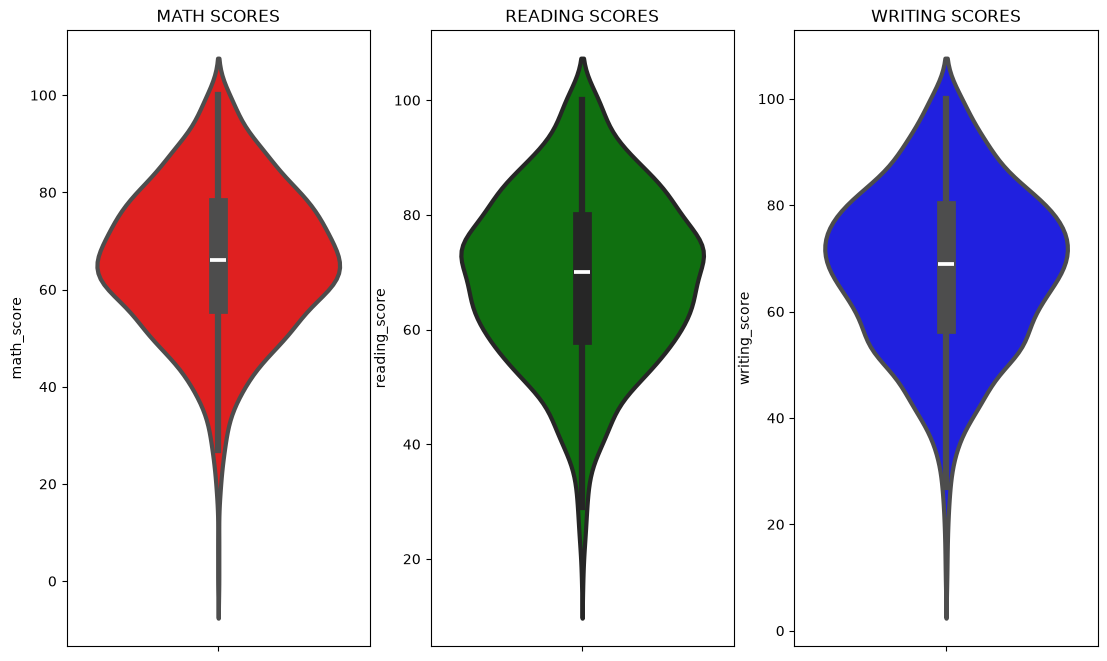

In [21]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()
